In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:\\Users\\ASUS\\OneDrive\\Desktop\\AI Intern Assessment\\data\\raw.csv')

In [ ]:
df['date'] = pd.to_datetime(df['date']) #convert string dates to actual datetime objects
df.set_index('date', inplace=True)   #make date index so time-based operation

print(df.head())
print(df.info())
print(df.describe())

                     Appliances  lights     T1       RH_1    T2       RH_2  \
date                                                                         
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

                        T3       RH_3         T4       RH_4  ...         T9  \
date                                                         ...              
2016-01-11 17:00:00  19.79  44.730000  19.000000  45.566667  ...  17.033333   
2016-01-11 17:10:00  19.79  44.790000  19.000000  45.992500  ...  17.066667   
2016-01-11 17:20:00  19.79  44.933333  18.926667  45.890000  ...  17.000000   
2016-01-11 17:30:00  19.79  45.000000  18.890000  45.72333

In [9]:
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicated rows: {df.duplicated().sum()}")



Shape: (19735, 28)

Missing values:
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

Duplicated rows: 0


There are no missing values to be found, nor any duplicate rows

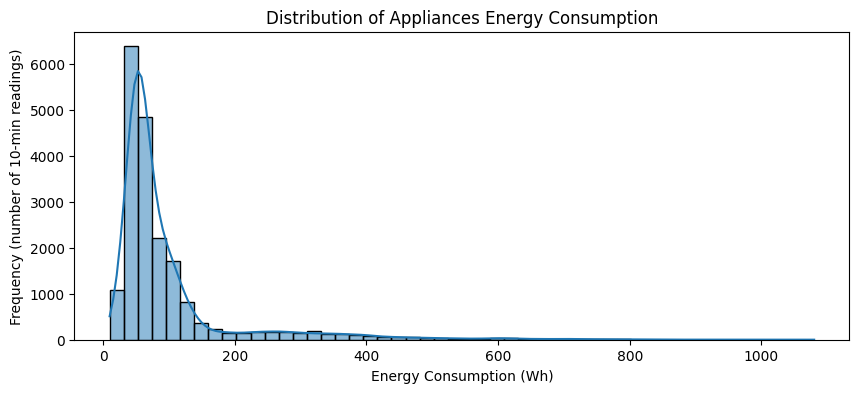

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(df['Appliances'], bins=50, kde=True)
plt.title('Distribution of Appliances Energy Consumption')
plt.xlabel('Energy Consumption (Wh)')
plt.ylabel('Frequency (number of 10-min readings)')
plt.show()

This chart shows the distribution of the Target variable, Appliances Energy consuption in WH.

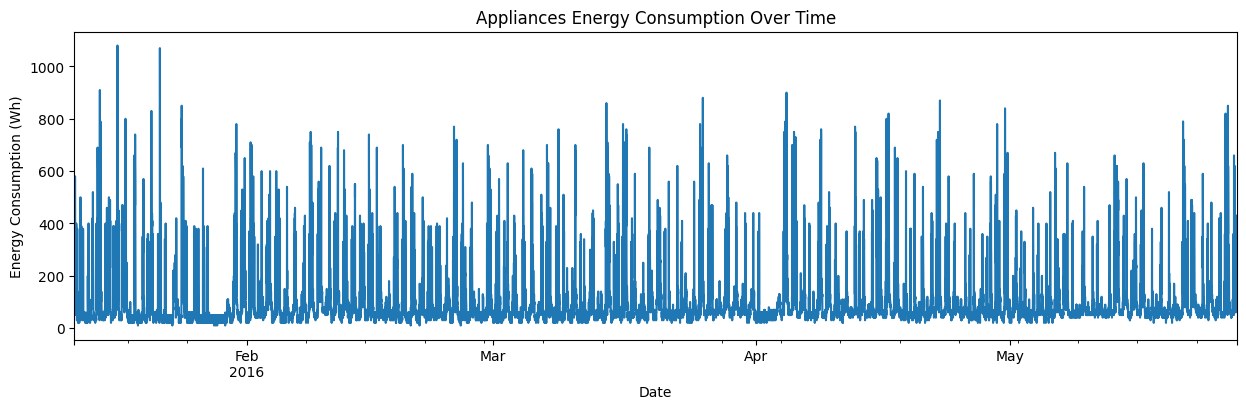

In [13]:
plt.figure(figsize=(15,4))
df['Appliances'].plot()
plt.title('Appliances Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.show()

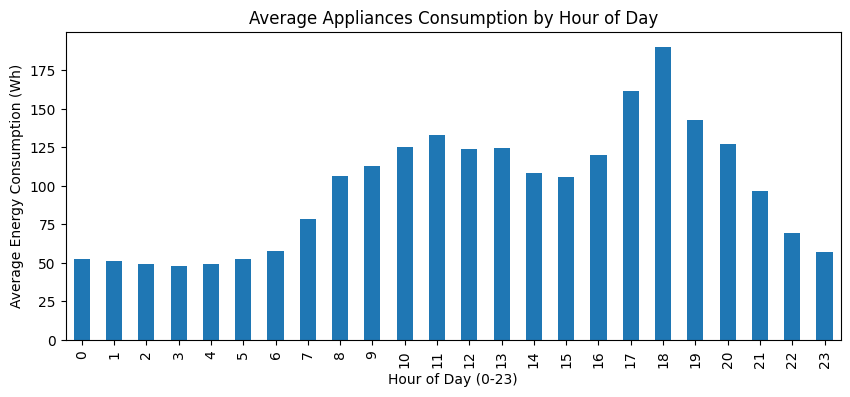

In [14]:
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['Appliances'].mean()

plt.figure(figsize=(10,4))
hourly_avg.plot(kind='bar')
plt.title('Average Appliances Consumption by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Energy Consumption (Wh)')
plt.show()

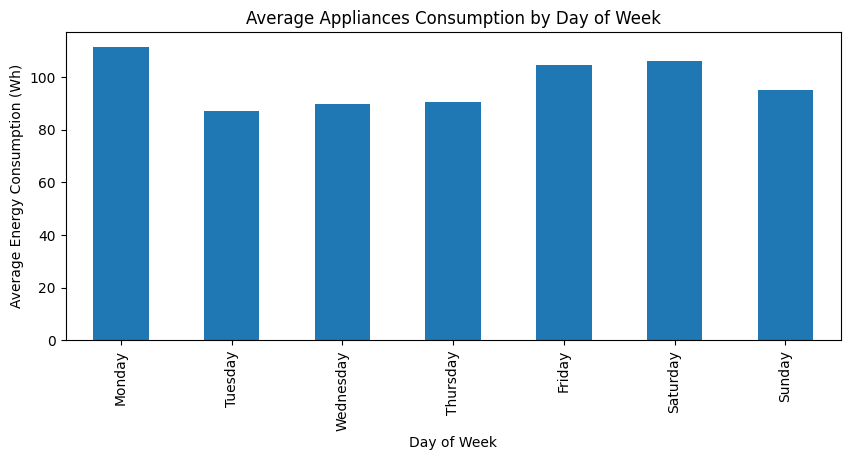

In [15]:
df['weekday'] = df.index.day_name()
weekday_avg = df.groupby('weekday')['Appliances'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,4))
weekday_avg.plot(kind='bar')
plt.title('Average Appliances Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Consumption (Wh)')
plt.show()

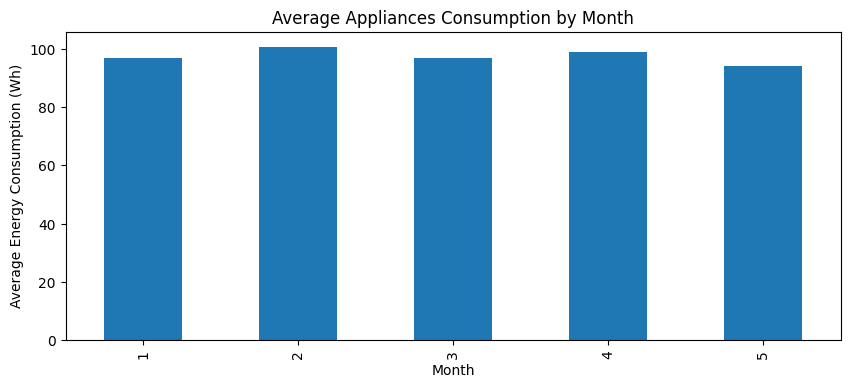

In [33]:
df['month'] = df.index.month_name()

monthly_avg = df.groupby(df.index.month)['Appliances'].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind='bar')
plt.title('Average Appliances Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (Wh)')
plt.show()

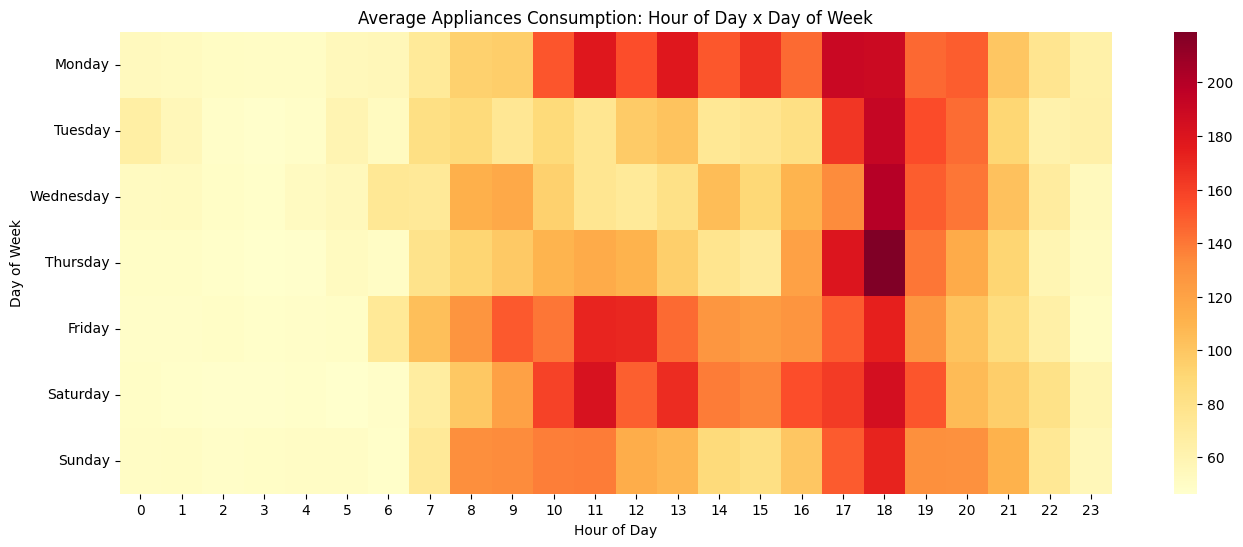

In [29]:
# Standout EDA plot: Hour of Day x Day of Week heatmap
# Reveals behavioral patterns a single bar chart can't show
# e.g. whether weekend mornings have a weaker peak than weekday mornings

df['dow_name'] = df.index.day_name()

pivot_hour_dow = df.pivot_table(values='Appliances', index='dow_name', columns='hour', aggfunc='mean')
pivot_hour_dow = pivot_hour_dow.reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_hour_dow, cmap='YlOrRd', annot=False)
plt.title('Average Appliances Consumption: Hour of Day x Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

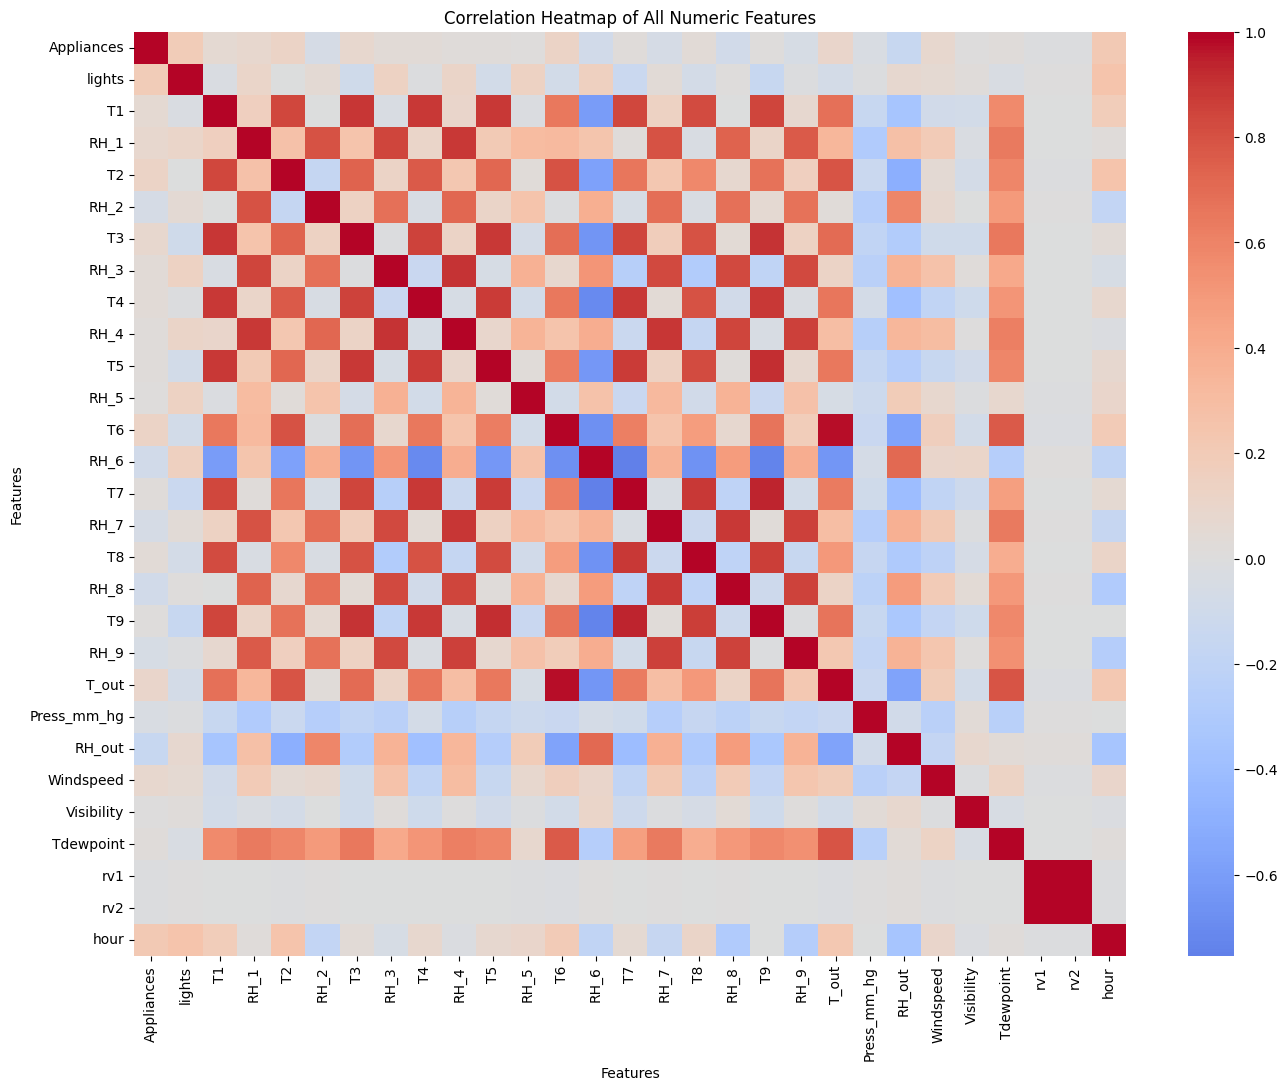

Appliances     1.000000
hour           0.216792
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015357
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


In [16]:
plt.figure(figsize=(16,12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of All Numeric Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

print(corr['Appliances'].sort_values(ascending=False))

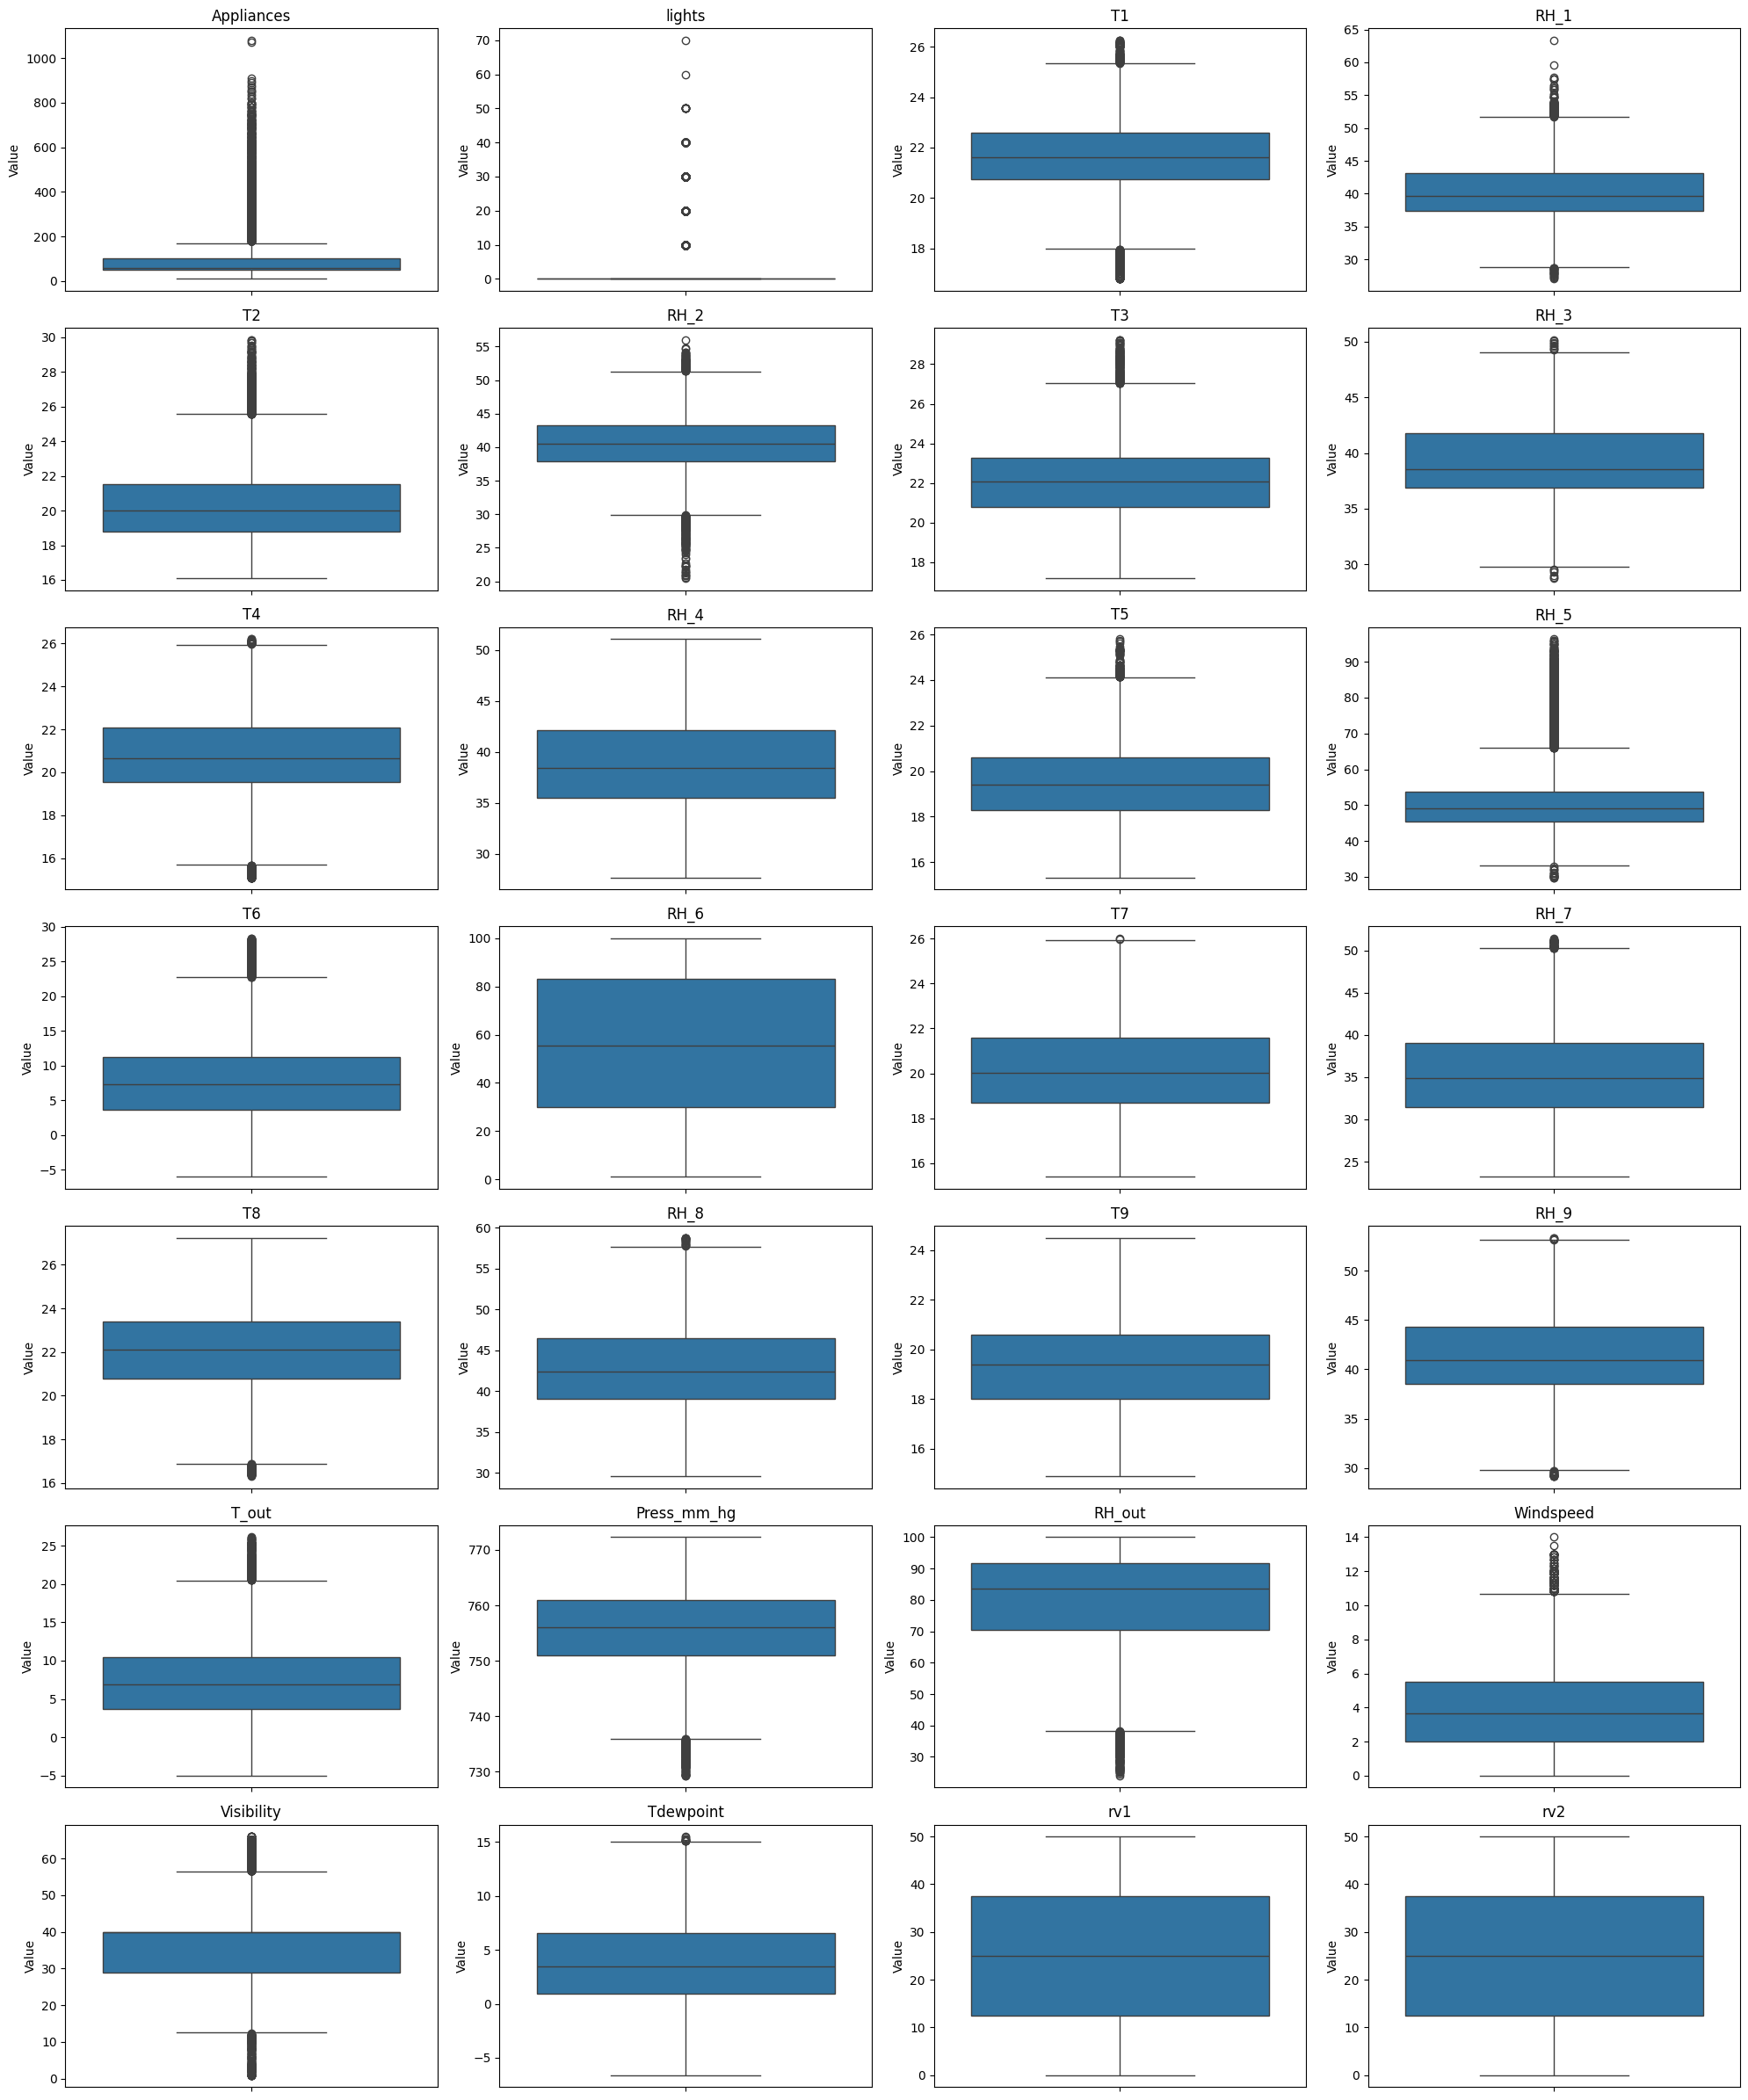

In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['hour'], errors='ignore')

fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [30]:
# IQR-based outlier count and percentage per numeric column
# Turns the visual box plot grid into concrete numbers for the report

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['hour'], errors='ignore')

outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        'count': len(outliers),
        'pct': round(len(outliers) / len(df) * 100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('pct', ascending=False)
print(outlier_df)

                count    pct
lights         4483.0  22.72
Visibility     2522.0  12.78
Appliances     2138.0  10.83
RH_5           1330.0   6.74
T2              546.0   2.77
T6              515.0   2.61
T1              515.0   2.61
T_out           440.0   2.23
T_indoor_avg    341.0   1.73
RH_out          239.0   1.21
RH_2            235.0   1.19
temp_diff       219.0   1.11
Press_mm_hg     219.0   1.11
T3              217.0   1.10
Windspeed       214.0   1.08
T4              186.0   0.94
T5              179.0   0.91
RH_1            146.0   0.74
T8               71.0   0.36
RH_7             42.0   0.21
RH_9             21.0   0.11
RH_8             17.0   0.09
RH_3             15.0   0.08
Tdewpoint        11.0   0.06
T7                2.0   0.01
RH_6              0.0   0.00
RH_4              0.0   0.00
T9                0.0   0.00
rv1               0.0   0.00
rv2               0.0   0.00
RH_indoor_avg     0.0   0.00


In [31]:
# Explicit noise-variable validation check
rv_corr = df[['rv1', 'rv2']].corrwith(df['Appliances'])
print("Correlation of rv1/rv2 with Appliances (expected: near zero):")
print(rv_corr)

Correlation of rv1/rv2 with Appliances (expected: near zero):
rv1   -0.011145
rv2   -0.011145
dtype: float64


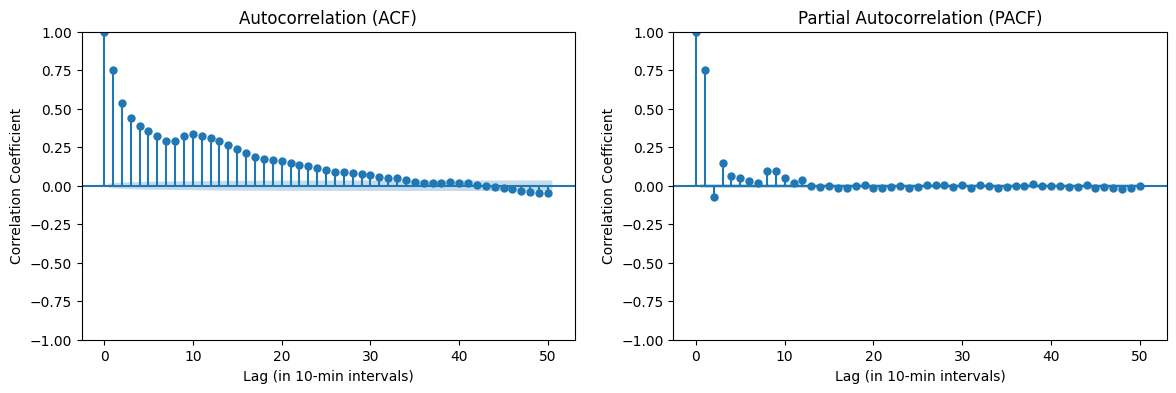

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))

plot_acf(df['Appliances'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
axes[0].set_xlabel('Lag (in 10-min intervals)')
axes[0].set_ylabel('Correlation Coefficient')

plot_pacf(df['Appliances'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)')
axes[1].set_xlabel('Lag (in 10-min intervals)')
axes[1].set_ylabel('Correlation Coefficient')

plt.show()

29.815 96.32166667


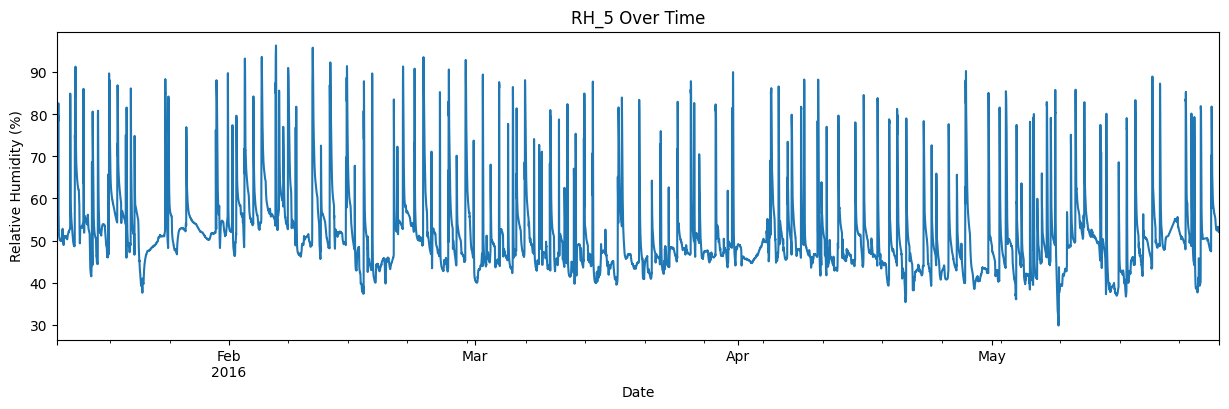

In [ ]:
# inorder confirm RH_5 "outliers" are real weather, not glitches
print(df['RH_5'].min(), df['RH_5'].max())  # check physical plausibility

plt.figure(figsize=(15,4))
df['RH_5'].plot()
plt.title('RH_5 Over Time')
plt.xlabel('Date')
plt.ylabel('Relative Humidity (%)')
plt.show()

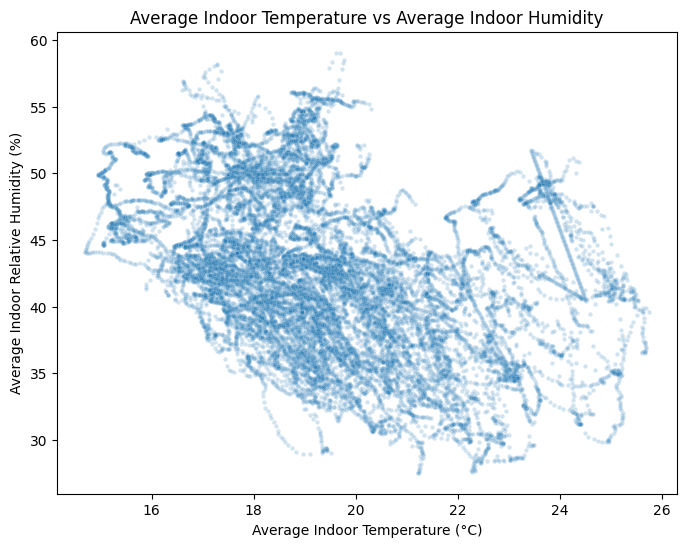

Correlation (T_indoor_avg vs RH_indoor_avg): -0.41709132528623083


In [ ]:
indoor_temp_cols = ['T1','T2','T3','T4','T5','T6','T7','T8','T9']
indoor_rh_cols = ['RH_1','RH_2','RH_3','RH_4','RH_5','RH_6','RH_7','RH_8','RH_9']

df['T_indoor_avg'] = df[indoor_temp_cols].mean(axis=1)
df['RH_indoor_avg'] = df[indoor_rh_cols].mean(axis=1)

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='T_indoor_avg', y='RH_indoor_avg', alpha=0.2, s=10)
plt.title('Average Indoor Temperature vs Average Indoor Humidity')
plt.xlabel('Average Indoor Temperature (°C)')
plt.ylabel('Average Indoor Relative Humidity (%)')
plt.show()

print("Correlation (T_indoor_avg vs RH_indoor_avg):", df['T_indoor_avg'].corr(df['RH_indoor_avg']))


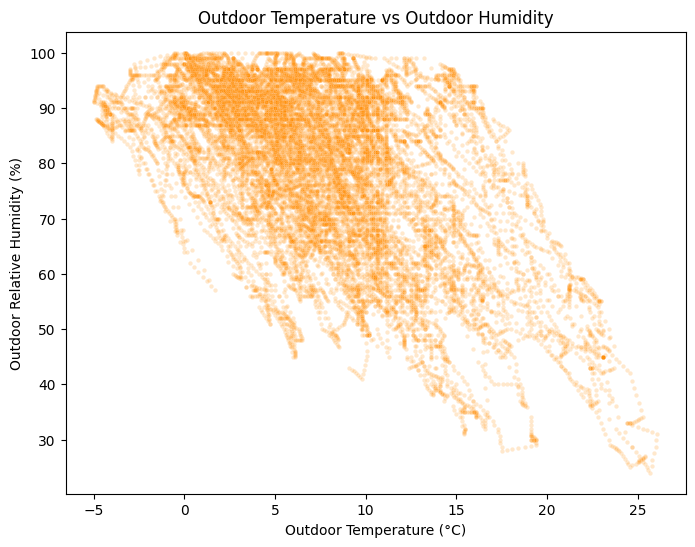

Correlation (T_out vs RH_out): -0.5741863665135615


In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='T_out', y='RH_out', alpha=0.2, s=10, color='darkorange')
plt.title('Outdoor Temperature vs Outdoor Humidity')
plt.xlabel('Outdoor Temperature (°C)')
plt.ylabel('Outdoor Relative Humidity (%)')
plt.show()

print("Correlation (T_out vs RH_out):", df['T_out'].corr(df['RH_out']))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_35740\585492761.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_indoor = df.pivot_table(values='Appliances', index='RH_indoor_bin',


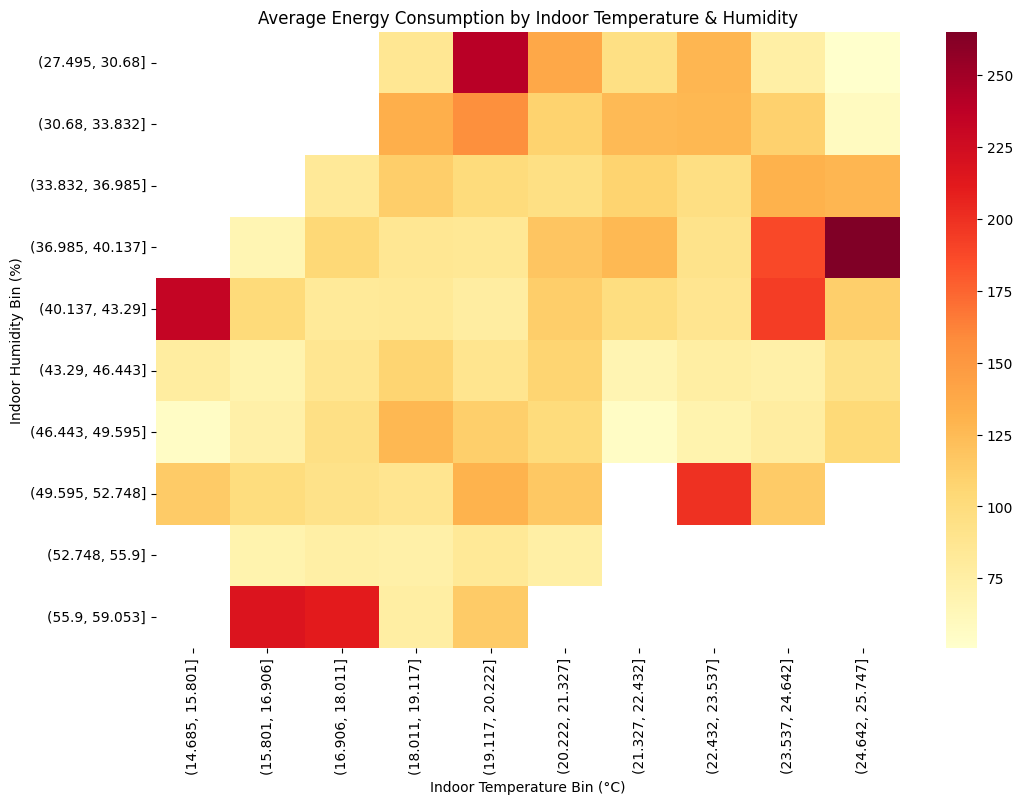

In [26]:
# Indoor climate vs energy consumption
df['T_indoor_bin'] = pd.cut(df['T_indoor_avg'], bins=10)
df['RH_indoor_bin'] = pd.cut(df['RH_indoor_avg'], bins=10)

pivot_indoor = df.pivot_table(values='Appliances', index='RH_indoor_bin',
                               columns='T_indoor_bin', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_indoor, cmap='YlOrRd', annot=False)
plt.title('Average Energy Consumption by Indoor Temperature & Humidity')
plt.xlabel('Indoor Temperature Bin (°C)')
plt.ylabel('Indoor Humidity Bin (%)')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_35740\2359292652.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_outdoor = df.pivot_table(values='Appliances', index='RH_out_bin',


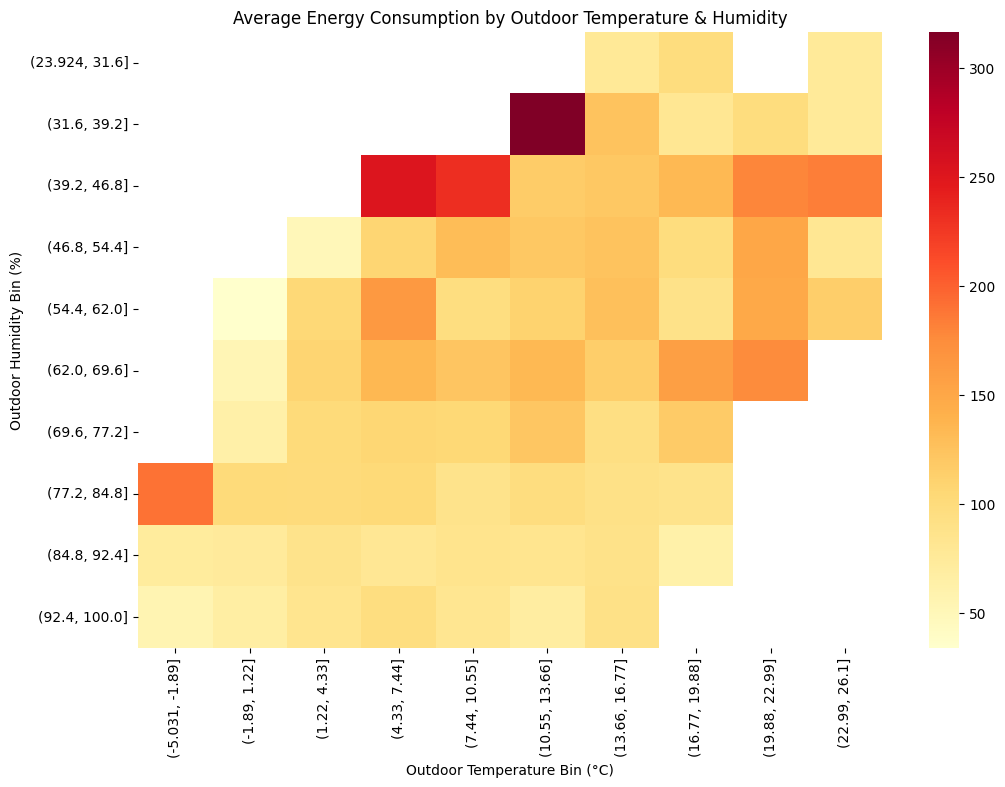

In [27]:
# Outdoor climate vs energy consumption
df['T_out_bin'] = pd.cut(df['T_out'], bins=10)
df['RH_out_bin'] = pd.cut(df['RH_out'], bins=10)

pivot_outdoor = df.pivot_table(values='Appliances', index='RH_out_bin',
                                columns='T_out_bin', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_outdoor, cmap='YlOrRd', annot=False)
plt.title('Average Energy Consumption by Outdoor Temperature & Humidity')
plt.xlabel('Outdoor Temperature Bin (°C)')
plt.ylabel('Outdoor Humidity Bin (%)')
plt.show()

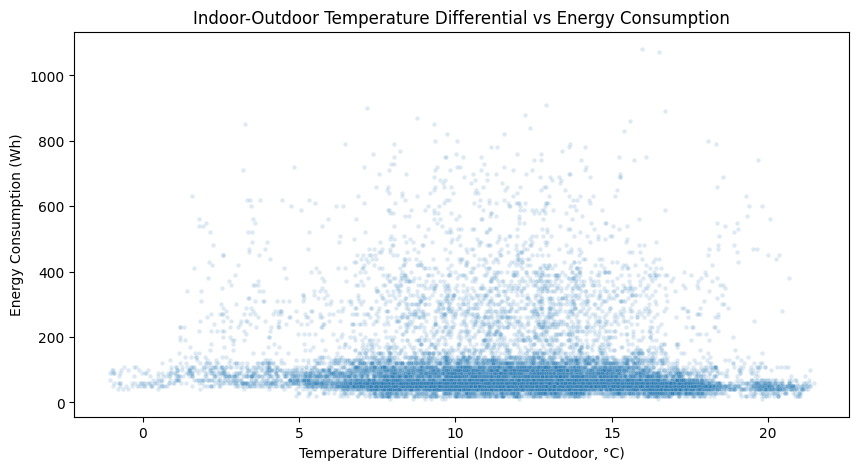

Correlation (temp_diff vs Appliances): -0.09781809660152141


In [28]:
df['temp_diff'] = df['T_indoor_avg'] - df['T_out']

plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='temp_diff', y='Appliances', alpha=0.15, s=10)
plt.title('Indoor-Outdoor Temperature Differential vs Energy Consumption')
plt.xlabel('Temperature Differential (Indoor - Outdoor, °C)')
plt.ylabel('Energy Consumption (Wh)')
plt.show()

print("Correlation (temp_diff vs Appliances):", df['temp_diff'].corr(df['Appliances']))